In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [4]:
try:
    cols_df = pd.read_csv(r"C:\Users\PC-032\Desktop\TakeHomeProject\census-bureau.columns", header=None)

    columns = [str(x).strip() for x in cols_df[0].tolist()]
    print("✅ Columns loaded successfully:", len(columns))
except Exception as e:
    print("File not found",e)
    columns = None

✅ Columns loaded successfully: 42


In [5]:
try:

    df = pd.read_csv(r"C:\Users\PC-032\Desktop\TakeHomeProject\census-bureau.data", names=columns, na_values=[' ?', '?'])
   
        
    print("Data loaded successfully!")
    print("Data Shape:", df.shape)
    
except Exception as e:
    print("Data file nahi mili! Path check karo.", e)


Data loaded successfully!
Data Shape: (199523, 42)


In [6]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [7]:
df['income_label'] = df['label'].astype(str).str.strip().apply(lambda x: 1 if '50000+.' in x else 0)

df['income_label'].value_counts() 

income_label
0    187141
1     12382
Name: count, dtype: int64

In [8]:
X = df.drop(columns=['label', 'income_label', 'year'], errors='ignore')
y = df['income_label']

In [9]:
print(X.isnull().sum()[df.isnull().sum() > 0])

hispanic origin                     874
state of previous residence         708
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
dtype: int64


In [10]:
# handeling NUll values
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
# ------------------------------------------------------------------------
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna('Unknown') 

In [11]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [12]:
# handeling duplicates
X = X.drop_duplicates()
y = y.loc[X.index]
df = df.loc[X.index]
df.duplicated().sum()

np.int64(119)

In [13]:
# handeling categorical data
categorical_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))
print(f"Converted {len(categorical_cols)} text columns to integers.")    

Converted 28 text columns to integers.


In [14]:
print(f"X shape: {X.shape}")
print(f"df shape: {df.shape}")
print(f"X.index length: {len(X.index)}")
print(f"df.index length: {len(df.index)}")
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(cat_cols)}")
if len(cat_cols) > 0:
    print(f"First cat col ({cat_cols[0]}) length: {len(df[cat_cols[0]])}")

X shape: (196293, 40)
df shape: (196293, 43)
X.index length: 196293
df.index length: 196293
Categorical columns: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'label']
First cat col (class of worker) length: 196293


In [15]:
# outlier handeling
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    X[col] = X[col].clip(lower_limit, upper_limit)

In [16]:
cat_cols_in_df = df.select_dtypes(include=['object']).columns
cat_cols_in_X = X.select_dtypes(include=['object']).columns
print(f"Categorical columns in df: {list(cat_cols_in_df)}")
print(f"Categorical columns in X: {list(cat_cols_in_X)}")
print(f"Columns in df but not in X: {set(cat_cols_in_df) - set(cat_cols_in_X)}")

Categorical columns in df: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'label']
Categorical columns in X: []
Columns in df but not in X: {'detailed household summary in household', 'enroll in edu inst last wk', "fill inc questionnaire for veteran's admin", 'hispanic origin', 'migration prev res in 

In [17]:

correlations = X.corrwith(y).sort_values(ascending=False)
print("\n--- Correlation of Features with Target ---\n", correlations)

c:\Users\PC-032\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\PC-032\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



--- Correlation of Features with Target ---
 weeks worked in year                          0.260398
num persons worked for employer               0.220578
detailed industry recode                      0.193879
sex                                           0.159255
family members under 18                       0.148168
age                                           0.132446
class of worker                               0.132398
major occupation code                         0.097434
education                                     0.095515
detailed household and family stat            0.075070
detailed household summary in household       0.068640
migration code-change in msa                  0.020370
full or part time employment stat             0.019299
weight                                        0.017524
live in this house 1 year ago                 0.016193
migration prev res in sunbelt                 0.014930
detailed occupation recode                    0.010198
migration code-move

In [18]:
y.value_counts()

income_label
0    183911
1     12382
Name: count, dtype: int64

In [19]:
threshold = 0.01
relevant_features = correlations[abs(correlations) > threshold].index.tolist()
X = X[relevant_features]
print(f"Relevant columns bache: {len(X.columns)}")
print("New columns list:", X.columns.tolist())

Relevant columns bache: 20
New columns list: ['weeks worked in year', 'num persons worked for employer', 'detailed industry recode', 'sex', 'family members under 18', 'age', 'class of worker', 'major occupation code', 'education', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'full or part time employment stat', 'weight', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'detailed occupation recode', 'major industry code', 'tax filer stat', 'marital stat']


In [20]:
X.shape,y.shape

((196293, 20), (196293,))

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


rf_model = RandomForestClassifier(n_estimators=150, 
    max_depth=15,        
    min_samples_split=5, 
    random_state=42, 
    class_weight='balanced')

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [23]:
rf_model.score(X_test, y_test),rf_model.score(X_train, y_train)

(0.8833897959703507, 0.8989390832558554)

 Adjusting Threshold for Business ROI

 --- BUSINESS LOGIC: PRECISION-FOCUS THRESHOLD ---
 Instead of the default 0.5, we use 0.7 to ensure we only target 
 individuals with a very high probability of being high-earners.
-------------------------------------------------------------------------
y_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= 0.7).astype(int)

from sklearn.metrics import classification_report
print("Classification Report at 0.7 Threshold:")
print(classification_report(y_test, y_pred_custom))

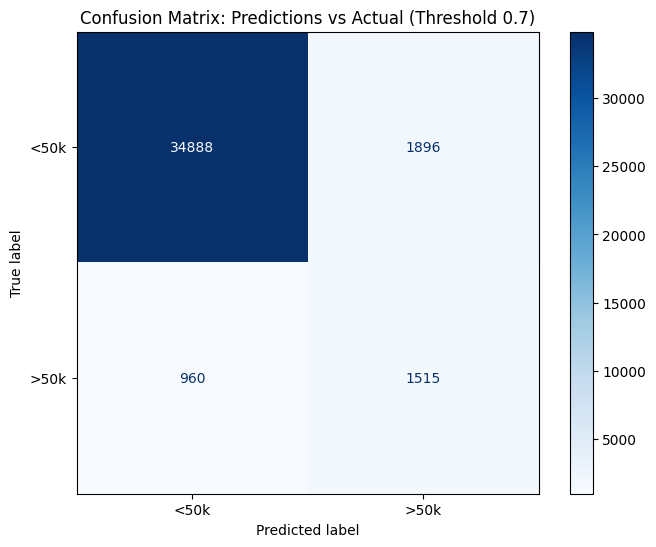

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     36784
           1       0.44      0.61      0.51      2475

    accuracy                           0.93     39259
   macro avg       0.71      0.78      0.74     39259
weighted avg       0.94      0.93      0.93     39259



In [24]:
#  Evaluation Metrics: Accuracy, F1-Score, Recall
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_probs = rf_model.predict_proba(X_test)[:, 1]
threshold = 0.7
y_pred_strict = (y_probs >= threshold).astype(int)
cm_new = confusion_matrix(y_test, y_pred_strict)


disp = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['<50k', '>50k'])

# Plot settings
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Predictions vs Actual (Threshold 0.7)")
plt.show()
print(classification_report(y_test, y_pred_strict))

C:\Users\PC-032\AppData\Local\Temp\ipykernel_11532\3757142491.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


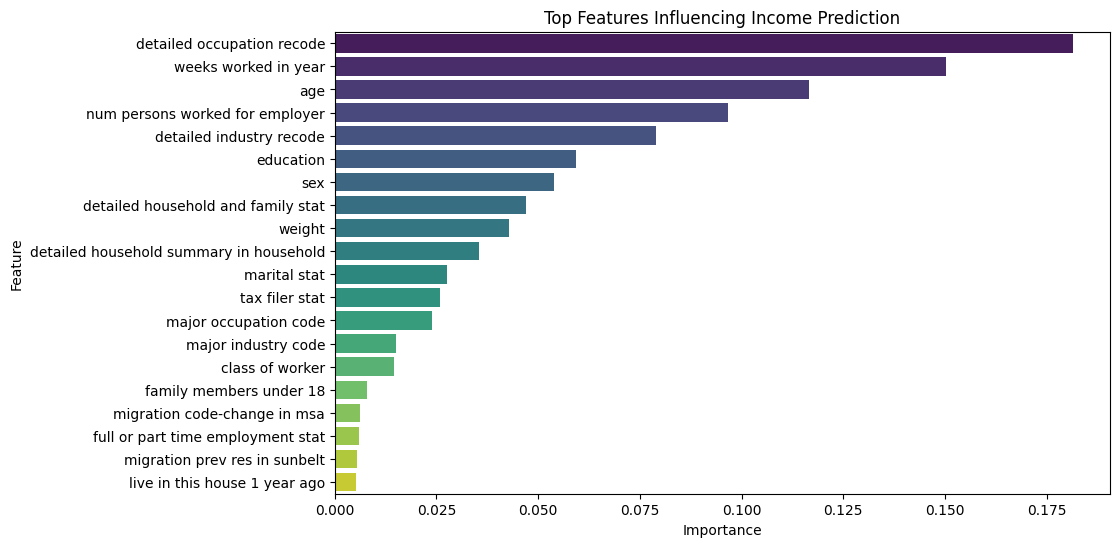

In [25]:
# Feature importances 
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot karein
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Features Influencing Income Prediction')
plt.show()

In [26]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation (Accuracy check)
# model is stable at accuracy or not 
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print(f"All CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

All CV Scores: [0.8829313  0.88125016 0.88249828 0.88162922 0.87954048]
Mean CV Accuracy: 0.8816
Standard Deviation: 0.0012


In [27]:
import joblib

# Model save karein
model_data = {
    'classifier': rf_model,
    'features': list(X.columns),
    'threshold': 0.7
}

joblib.dump(model_data, 'census_income_final_model.pkl')
print("Model, Feature list, and Threshold saved as 'census_income_final_model.pkl'")

Model, Feature list, and Threshold saved as 'census_income_final_model.pkl'


#   segmentations model-------------------------------------------

In [28]:
# Selecting columns that represent customer behavior/demographics
segment_cols = ['age', 'education', 'marital stat', 'major occupation code', 
                'sex', 'weeks worked in year', 'capital gains','income_label']

# Create a new dataframe for clustering
df_cluster = df[segment_cols].copy()

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical data first
le = LabelEncoder()
for col in df_cluster.select_dtypes(include=['object']).columns:
    df_cluster[col] = le.fit_transform(df_cluster[col].astype(str))

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

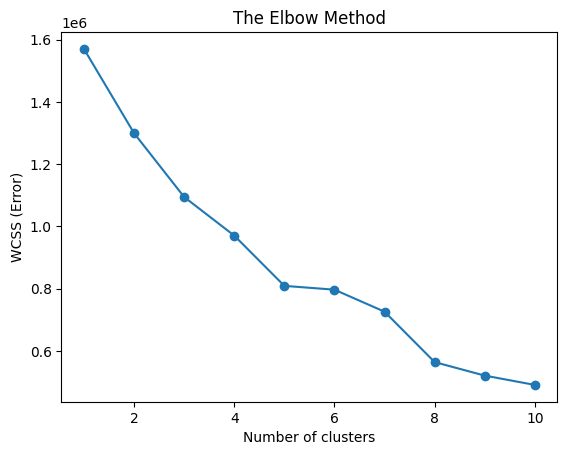

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Error)')
plt.show()

In [31]:
from sklearn.cluster import KMeans

# Initialize and fit K-Means with the chosen elbow point
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Segment'] = kmeans.fit_predict(df_scaled)

# Let's see how many people fell into each segment
print(df['Segment'].value_counts())

Segment
3    76365
0    66927
1    40573
4    12038
2      390
Name: count, dtype: int64


In [32]:
# 1. Ensure income_col is correct
income_col = 'income_label'

# 2. Calculate High Income Rate safely
def calculate_high_income(x):
    # If the column is still text/strings
    if x.dtype == 'object':
        return (x.str.contains('>50K')).mean() * 100
    # If the column is already numeric (0 and 1)
    else:
        # Assuming 1 is >50K and 0 is <=50K
        return x.mean() * 100

high_income_stats = df.groupby('Segment')[income_col].apply(calculate_high_income).reset_index(name='High_Income_Percent')

# 3. Get average numeric profiles
numeric_profiles = df.groupby('Segment')[['age', 'capital gains', 'weeks worked in year']].mean()

# 4. Get most common Occupation (Mode)
common_jobs = df.groupby('Segment')['major occupation code'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")

# 5. Final Marketing Table
marketing_report = pd.concat([numeric_profiles, common_jobs], axis=1).reset_index()
marketing_report = marketing_report.merge(high_income_stats, on='Segment')

print("--- FINAL MARKETING SEGMENTATION REPORT ---")
print(marketing_report.sort_values(by='High_Income_Percent', ascending=False))

--- FINAL MARKETING SEGMENTATION REPORT ---
   Segment        age  capital gains  weeks worked in year  \
4        4  46.241319    2111.390596             48.004486   
2        2  46.869231   99999.000000             47.458974   
0        0  11.811765       8.645046              3.290615   
1        1  62.216942     113.510882              2.308654   
3        3  38.847522     224.393937             48.624370   

            major occupation code  High_Income_Percent  
4  Executive admin and managerial           100.000000  
2          Professional specialty            88.205128  
0                 Not in universe             0.000000  
1                 Not in universe             0.000000  
3  Adm support including clerical             0.000000  


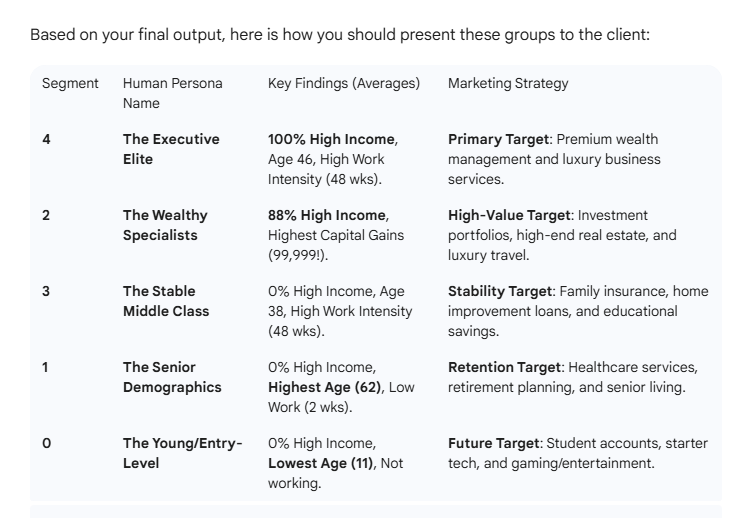

In [33]:
from IPython.display import Image, display
display(Image(filename=r"C:\Users\PC-032\Desktop\Takehome_coding\seganmentation_output.png"))

In [34]:
df.to_csv('Final_Customer_Segmentation_Results.csv', index=False)

In [35]:
import joblib

# Create a dictionary to keep everything organized
clustering_assets = {
    'scaler': df_scaled, # Or the scaler object you used
    'model': kmeans,
    'features': segment_cols
}

# Save it as a single file
joblib.dump(clustering_assets, 'customer_segmentation_model.pkl')
print("Segmentation model saved successfully!")

Segmentation model saved successfully!
